In [9]:
from typing import Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from IPython.display import Image, display
import gradio as gr
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
#from langchain_openai import ChatOpenAI
from langchain_ollama import ChatOllama
from pydantic import BaseModel
from typing import TypedDict
import random


llm = ChatOllama(model="gpt-oss:20b")

In [10]:

class State(TypedDict):
    messages: Annotated[list, add_messages]
    users_question: str
    category_of_problem:str
    requested_id: str
    user_status: str

### External functions

In [27]:
def get_user_id() -> str:
    return "B123456"

def get_users_status(user_id:str) -> str:
    if user_id == "A123456":
        return "New"
    elif user_id == "B123456":
        return "Active"
    return "New"

def get_random_category(user_input:str) -> str:
    """
    Returns a random category for a given user question.
    """
    categories = [
        "User Access",
        "Check Access",
        "Other"
    ]
    
    # Pick a random category
    return random.choice(categories)

### Tool functions

In [36]:
def get_solution_to_problem(problem_category: str, user_status: str) -> str:
    """ Function that will return instructions and steps to follow for a users question"""
    categories = {
        "User Access": {
            "New": [
                "Create a new user account in the system.",
                "Assign default roles and permissions.",
                "Send account setup instructions to the user.",
                "Confirm the user can log in."
            ],
            "Active": [
                "Verify the account is not locked or disabled.",
                "Reset password if login issues persist.",
                "Ensure MFA or security settings are configured correctly.",
                "Test login access with the user."
            ],
            "Existing": [
                "Confirm the user’s current roles and permissions.",
                "Check if recent changes affected their access.",
                "Update permissions if needed.",
                "Validate the user can access required resources."
            ]
        },
        "Check Access": {
            "New": [
                "Ensure the user has been assigned to the correct groups.",
                "Grant access based on role requirements.",
                "Confirm new user policies are applied correctly.",
                "Test access with sample resource requests."
            ],
            "Active": [
                "Check if permissions match the user’s role.",
                "Review audit logs for denied access attempts.",
                "Reapply or update role policies if needed.",
                "Confirm access with the user."
            ],
            "Existing": [
                "Verify that the resource hasn’t changed ownership or policy.",
                "Check if the user’s role was recently updated or revoked.",
                "Restore missing permissions if appropriate.",
                "Confirm access to the required resource."
            ]
        },
        "Other": {
            "New": [
                "Collect details about the issue during onboarding.",
                "Check standard onboarding documentation.",
                "Escalate to system administrator if setup fails."
            ],
            "Active": [
                "Gather logs and error details from the user.",
                "Search knowledge base for related issues.",
                "Apply known fixes or escalate as needed."
            ],
            "Existing": [
                "Review historical tickets for similar issues.",
                "Investigate if the issue is recurring.",
                "Apply a long-term fix or escalate to engineering."
            ]
        }
    }
    print("Looking for solution for", problem_category, "where status", user_status)
    if categories[problem_category] and categories[problem_category][user_status]:
        print("Provide solution", str(categories[problem_category][user_status]))
        return str(categories[problem_category][user_status])
    return "Not able to help with this request"

#### Setup tool functions

In [13]:
from langchain.agents import Tool
solver_tool = Tool(
        name="question_solver",
        func=get_solution_to_problem,
        description="Get steps for a users to take when given a users status an question catgory"
    )
tools=[solver_tool]
llm_with_tools = llm.bind_tools(tools)

In [42]:
from langchain_core.messages import SystemMessage, HumanMessage
def get_id_node(state: State) -> State:
    return {"requested_id": get_user_id()}

def get_category_node(state: State) -> State:
    return {"user_status": get_users_status(state["requested_id"])}

def categorize_user_problem_node(state: State) -> State:
    return {"category_of_problem": get_random_category(state["users_question"])}

def chatbot_node(state: State) -> State:
    
    messages = [
        SystemMessage("You are an agent who will recive a question and then provide the users steps. You will recive how the users " \
        "how question is categorized and a users status and the orginal question they asked. Once you have the answer say what it is"),
        HumanMessage(f" question cateogory= {state["category_of_problem"]}, users status = {state["user_status"]}, queston={state["users_question"]}")
    ]
    state["messages"] += messages
    response = llm_with_tools.invoke(state["messages"])
    print(response)
    return {"messages": [response] }


#### Condtional functions

In [15]:
import re

def is_valid_id(state: State) -> str:
    requested_id = state["requested_id"]
    # Pattern: one letter, followed by exactly 6 digits
    pattern = r"^[A-Za-z]\d{6}$"
    
    if re.match(pattern, requested_id):
        return "check_accesses"
    else:
        return "invalid_id"

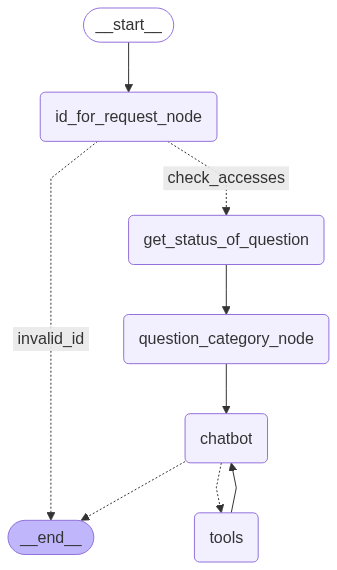

In [43]:
from langgraph.prebuilt import ToolNode, tools_condition
#Create graph
graph_builder = StateGraph(State)

#Add nodes
graph_builder.add_node("id_for_request_node",get_id_node)
graph_builder.add_node("get_status_of_question",get_category_node)
graph_builder.add_node("question_category_node", categorize_user_problem_node)
graph_builder.add_node("chatbot", chatbot_node)
graph_builder.add_node("tools", ToolNode(tools=tools))

#Add edges
graph_builder.add_edge(START, "id_for_request_node")
graph_builder.add_conditional_edges("id_for_request_node", is_valid_id, {"check_accesses": "get_status_of_question", "invalid_id" : END })
graph_builder.add_edge("get_status_of_question", "question_category_node")
graph_builder.add_edge("question_category_node", "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("chatbot", END)
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
def chat(user_input: str, history):
    result = graph.invoke({"users_question": user_input})
    print(result)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.


content='' additional_kwargs={} response_metadata={'model': 'gpt-oss:20b', 'created_at': '2025-08-19T01:19:36.6233283Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2737724000, 'load_duration': 80876600, 'prompt_eval_count': 206, 'prompt_eval_duration': 345887900, 'eval_count': 140, 'eval_duration': 2308563000, 'model_name': 'gpt-oss:20b'} id='run--b782c008-e98c-421f-aace-cd54ba7603e2-0' tool_calls=[{'name': 'question_solver', 'args': {'__arg1': "category: User Access; status: Active; question: can't log in"}, 'id': 'ff9ee6d1-147d-4b7c-a83c-84d5be011315', 'type': 'tool_call'}] usage_metadata={'input_tokens': 206, 'output_tokens': 140, 'total_tokens': 346}
content='**Steps for a user who is “Active” but can’t log in (User Access issue):**\n\n1. **Verify the login credentials**  \n   - Make sure you’re typing the correct username/email and password.  \n   - Double‑check the “Caps Lock” and “Num Lock” keys are in the expected state.\n\n2. **Reset the password**  \n   - Click **